# 02 — Tren MRR per Metode (Top-1 s/d Top-10)

**Pertanyaan yang dijawab:** Seberapa baik setiap metode menempatkan chunk relevan di posisi ranking teratas?

**Cara baca:** MRR (Mean Reciprocal Rank) = rata-rata dari 1/rank untuk chunk relevan pertama yang ditemukan. MRR=1.0 artinya chunk relevan selalu di posisi pertama; MRR=0 artinya tidak pernah ditemukan.

> **Prasyarat:** Jalankan `00_load_data.ipynb` terlebih dahulu.

## 1. Import & Load Cache

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PKL_DIR = Path("_cache")

with open(PKL_DIR / "data_eval.pkl", "rb") as f:
    cache = pickle.load(f)

all_df  = cache["all_df"]
FIG_DIR = cache["FIG_DIR"]

METHOD_ORDER  = ["Element-Based", "MaxMin Semantic", "Recursive"]
METHOD_COLORS = {
    "Element-Based":   "#2196F3",
    "MaxMin Semantic": "#FF9800",
    "Recursive":       "#4CAF50",
}
METHOD_MARKERS = {"Element-Based": "o", "MaxMin Semantic": "s", "Recursive": "^"}

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35,
})
print(f"Data loaded: {all_df.shape[0]} rows")

Data loaded: 900 rows


## 2. Hitung Rata-rata MRR per Top-k per Metode

In [2]:
trend = (
    all_df
    .groupby(["top_k", "method"])["mrr"]
    .mean()
    .reset_index()
    .rename(columns={"mrr": "mean_mrr"})
)

trend.pivot(index="top_k", columns="method", values="mean_mrr").round(4)

method,Element-Based,MaxMin Semantic,Recursive
top_k,,,
1,0.2857,0.2069,0.3448
2,0.3036,0.2931,0.3966
3,0.3274,0.3161,0.3966
4,0.3542,0.3420,0.4224
5,0.3542,0.3488,0.4293
6,0.3661,0.3546,0.4408
7,0.3661,0.3546,0.4408
8,0.3750,0.3546,0.4408
9,0.3750,0.3584,0.4408


## 3. Plot

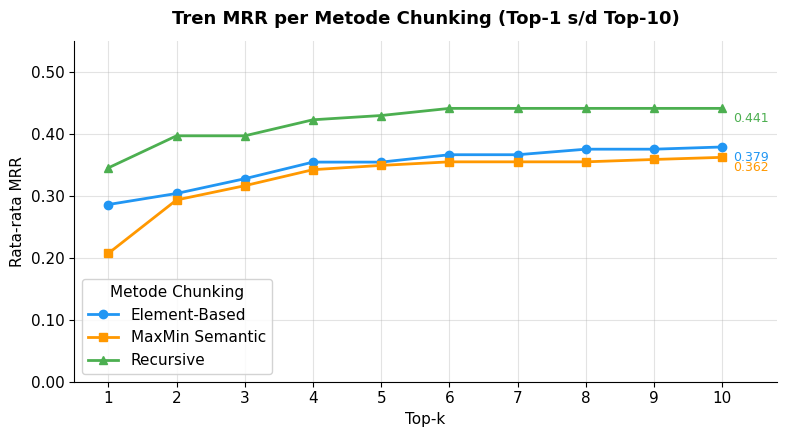

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for method in METHOD_ORDER:
    d = trend[trend["method"] == method].sort_values("top_k")
    ax.plot(
        d["top_k"], d["mean_mrr"],
        color=METHOD_COLORS[method],
        marker=METHOD_MARKERS[method],
        linewidth=2, markersize=6,
        label=method,
    )
    last = d[d["top_k"] == 10].iloc[0]
    ax.annotate(
        f"{last['mean_mrr']:.3f}",
        xy=(10, last["mean_mrr"]),
        xytext=(8, -10), textcoords="offset points",
        fontsize=9, color=METHOD_COLORS[method],
    )

ax.set_xlabel("Top-k")
ax.set_ylabel("Rata-rata MRR")
ax.set_title(
    "Tren MRR per Metode Chunking (Top-1 s/d Top-10)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.5, 10.8)
ax.set_ylim(0, 0.55)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(title="Metode Chunking", framealpha=0.85)

fig.tight_layout()
plt.show()

## 4. Simpan PNG

In [4]:
out_path = FIG_DIR / "02_mrr_trend.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Tersimpan: {out_path.resolve()}")

Tersimpan: D:\My Files\Kuliah\SKRIPSI\rag-skripsi\results\final\figures\02_mrr_trend.png

## 5. Interpretasi

- **Recursive** unggul MRR di semua top-k (0.34 → 0.44), artinya chunk relevan lebih sering berada di ranking teratas.
- **Element-Based** menyusul (0.29 → 0.38), **MaxMin Semantic** paling rendah di top-1 (0.21) tapi mengejar di k≥5.
- MRR cenderung **plateau** setelah k≥6 — menambah k lebih besar tidak banyak membantu ranking.
- Bandingkan dengan Recall@k (notebook `01`): Recursive recall lebih rendah tapi MRR lebih tinggi → chunk relevan Recursive sedikit tapi langsung di posisi atas.